# MobileNet V3 large

In [15]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 67

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [16]:
DATA_DIR = "../data"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

assert os.path.exists(IMAGENETTE_PATH), f"Imagenette not found at {IMAGENETTE_PATH}"
print("Imagenette found, reusing existing download.")

Imagenette found, reusing existing download.


In [17]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [18]:
class HSigmoid(nn.Module):
    def forward(self, x):
        return nn.functional.relu6(x + 3.0, inplace=True) / 6.0


class HSwish(nn.Module):
    def __init__(self):
        super().__init__()
        self.hsigmoid = HSigmoid()

    def forward(self, x):
        return x * self.hsigmoid(x)

In [19]:
class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        reduced = max(8, channels // reduction)
        self.fc1 = nn.Conv2d(channels, reduced, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Conv2d(reduced, channels, kernel_size=1)
        self.hsigmoid = HSigmoid()

    def forward(self, x):
        scale = self.avgpool(x)
        scale = self.relu(self.fc1(scale))
        scale = self.hsigmoid(self.fc2(scale))
        return x * scale

In [20]:
class MobileBottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride,
                 expand_size, use_se, use_hswish):
        super().__init__()
        self.use_residual = (stride == 1 and in_channels == out_channels)
        activation = HSwish if use_hswish else lambda: nn.ReLU(inplace=True)
        padding = kernel_size // 2

        layers = []
        if expand_size != in_channels:
            layers += [
                nn.Conv2d(in_channels, expand_size, kernel_size=1, bias=False),
                nn.BatchNorm2d(expand_size),
                activation(),
            ]

        layers += [
            nn.Conv2d(expand_size, expand_size, kernel_size=kernel_size, stride=stride,
                      padding=padding, groups=expand_size, bias=False),
            nn.BatchNorm2d(expand_size),
        ]

        if use_se:
            layers.append(SqueezeExcitation(expand_size))

        layers.append(activation())

        layers += [
            nn.Conv2d(expand_size, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        ]

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)

In [21]:
class MobileNetV3Large(nn.Module):

    bottleneck_config = [
        (3,  16,  16, False, False, 1),
        (3,  64,  24, False, False, 2),
        (3,  72,  24, False, False, 1),
        (5,  72,  40, True,  False, 2),
        (5, 120,  40, True,  False, 1),
        (5, 120,  40, True,  False, 1),
        (3, 240,  80, False, True,  2),
        (3, 200,  80, False, True,  1),
        (3, 184,  80, False, True,  1),
        (3, 184,  80, False, True,  1),
        (3, 480, 112, True,  True,  1),
        (3, 672, 112, True,  True,  1),
        (5, 672, 160, True,  True,  2),
        (5, 960, 160, True,  True,  1),
        (5, 960, 160, True,  True,  1),
    ]

    def __init__(self, num_classes=10):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            HSwish(),
        )

        layers = []
        in_channels = 16
        for kernel_size, expand_size, out_channels, use_se, use_hswish, stride in self.bottleneck_config:
            layers.append(MobileBottleneck(
                in_channels, out_channels, kernel_size, stride,
                expand_size, use_se, use_hswish,
            ))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        last_expand = 960
        self.final_conv = nn.Sequential(
            nn.Conv2d(in_channels, last_expand, kernel_size=1, bias=False),
            nn.BatchNorm2d(last_expand),
            HSwish(),
        )

        self.avgpool = nn.AdaptiveAvgPool2d(1)

        classifier_hidden = 1280
        self.classifier = nn.Sequential(
            nn.Conv2d(last_expand, classifier_hidden, kernel_size=1),
            HSwish(),
            nn.Dropout(0.2),
            nn.Conv2d(classifier_hidden, num_classes, kernel_size=1),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.final_conv(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x.flatten(1)

model = MobileNetV3Large(num_classes=10).to(device)
print(model)

MobileNetV3Large(
  (stem): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): HSwish(
      (hsigmoid): HSigmoid()
    )
  )
  (features): Sequential(
    (0): MobileBottleneck(
      (block): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (1): MobileBottleneck(
      (block): Sequential(
        (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, 

In [22]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [64, 10]

Output shape: torch.Size([64, 10])


In [23]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total MobileNetV3-Large parameters: {total_params:,}")

small_blocks = 11
large_blocks = len(model.bottleneck_config)
print(f"\nMobileNetV3-Small bottleneck blocks: {small_blocks}")
print(f"MobileNetV3-Large bottleneck blocks: {large_blocks}")
print(f"Large also uses wider expand_size/channels throughout (e.g. final "
      f"conv 960 vs Small's 576, classifier hidden 1280 vs 1024)")

Total MobileNetV3-Large parameters: 4,213,008

MobileNetV3-Small bottleneck blocks: 11
MobileNetV3-Large bottleneck blocks: 15
Large also uses wider expand_size/channels throughout (e.g. final conv 960 vs Small's 576, classifier hidden 1280 vs 1024)


In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [25]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [26]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=3.0157 train_acc=0.2174 | val_loss=2.9102 val_acc=0.2800 | time=70.8s
Epoch 2/10 | train_loss=2.5576 train_acc=0.2660 | val_loss=2.2356 val_acc=0.3338 | time=70.6s
Epoch 3/10 | train_loss=2.3027 train_acc=0.3078 | val_loss=2.2499 val_acc=0.3697 | time=70.6s
Epoch 4/10 | train_loss=2.1779 train_acc=0.3342 | val_loss=2.2093 val_acc=0.4054 | time=70.3s
Epoch 5/10 | train_loss=2.0438 train_acc=0.3589 | val_loss=1.8920 val_acc=0.4069 | time=70.4s
Epoch 6/10 | train_loss=1.9987 train_acc=0.3786 | val_loss=2.0222 val_acc=0.4318 | time=70.5s
Epoch 7/10 | train_loss=1.9286 train_acc=0.3980 | val_loss=1.7506 val_acc=0.4634 | time=70.5s
Epoch 8/10 | train_loss=1.8488 train_acc=0.4113 | val_loss=1.9796 val_acc=0.4759 | time=70.3s
Epoch 9/10 | train_loss=1.8324 train_acc=0.4195 | val_loss=1.6594 val_acc=0.4950 | time=70.2s
Epoch 10/10 | train_loss=1.7533 train_acc=0.4430 | val_loss=1.5642 val_acc=0.5197 | time=70.4s


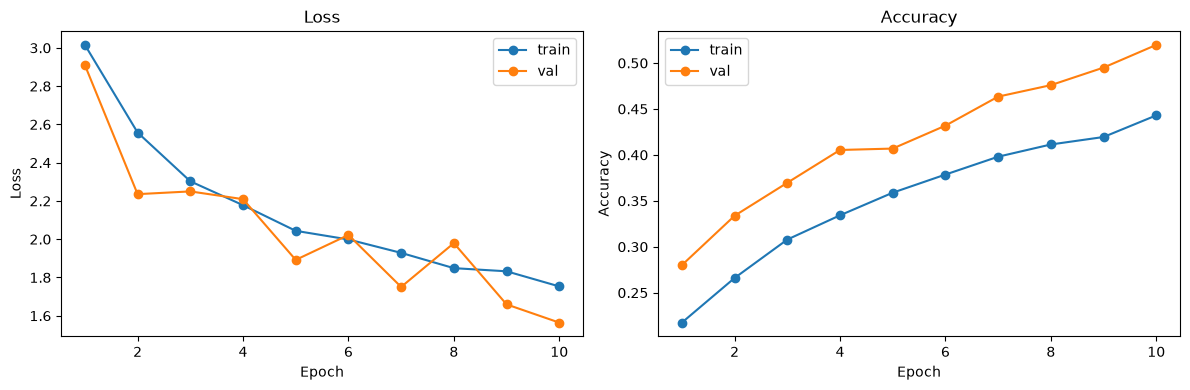

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

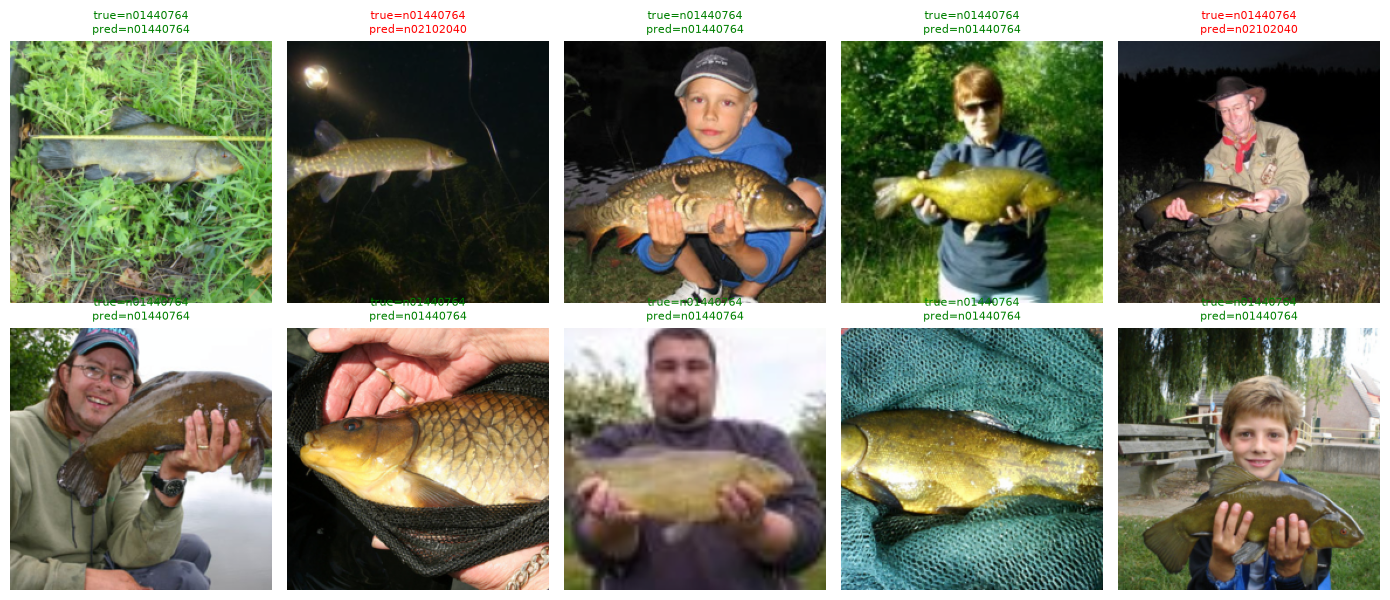

In [28]:
model.eval()

random_batch_idx = random.randint(0, len(val_loader) - 1)
for i, batch in enumerate(val_loader):
    if i == random_batch_idx:
        sample_images, sample_labels = batch
        break

class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: ~4.2M -
larger than MobileNetV3-Small (~4.2M vs ~1-2M) but still far smaller than
any ResNet/VGG/DenseNet variant in this repository, keeping the same
building blocks (h-swish, SE, mixed kernel sizes) but with more bottleneck
blocks (15 vs 11) and wider channels throughout, targeting a higher-compute
mobile budget than Small.

**Differences from Small beyond just "bigger".** Large omits SE from the
early, spatially-large layers (where it's most expensive per the paper's
latency analysis) and only introduces it starting partway through the
network, matching the pattern already seen in Small but shifted - both
follow the same design principle of using SE and h-swish more heavily in
the later, channel-rich, spatially-small layers where their computational
cost is lowest relative to the feature map size.

**Why Adam instead of RMSProp.** The original paper used RMSProp. We used
Adam for simpler, more reliable convergence without manual tuning.